In [27]:
import numpy as np  # import numerical python
import matplotlib.pyplot as plt  # import plotting functions
import seaborn as sns  # import nicer plotting functions
import polars as pl  # import polars to import data
import pandas as pd
import tifffile as tiff
from tifffile import imwrite, imread
from copy import deepcopy
import os
import time
from pathlib import Path
from copy import copy
from skimage.filters import gaussian
import xarray as xr
from scipy.spatial.distance import euclidean, cdist

import sys


from pyS3M import IOFunctions

IO = IOFunctions.IO_Functions()

from pyS3M import Multicolour_Simulation_Functions

MSF = Multicolour_Simulation_Functions.MultiC_Sim_Funcs()

from pyS3M import PSFFunctions

PSF = PSFFunctions.PSF_Functions()

from pyS3M import PlottingBase

plotter = PlottingBase.PublicationPlotter()

from pyS3M import ImageAnalysisFunctions

I_AF = ImageAnalysisFunctions.Image_Analysis_Functions()


from pyS3M import sCMOSFunctions
sCMOS = sCMOSFunctions.sCMOS_Functions()

from pyS3M import SpectralFunctions

S_F = SpectralFunctions.Spectral_Funcs()

from pyS3M import MaskFunctions

M_F = MaskFunctions.Mask_Functions()

from skimage.filters import gaussian, median

from pyS3M import HelperFunctions

H_F = HelperFunctions.Helper_Functions()

from pyS3M import NileRedFunctions

NR_F = NileRedFunctions.NileRed_Functions()

In [28]:
# data_folder = '/home/jbeckwith/Documents/Cambridge University Dropbox/Joseph Beckwith/Chemistry/Lee/Data/Salix/CS505CU_Calibration/old/'
data_folder = "../../../Camera_Calibrations/Ximea_Camera/"
gain = IO.read_tiff(os.path.join(data_folder, "gain.tif"))
offset = IO.read_tiff(os.path.join(data_folder, "offset.tif"))
variance = IO.read_tiff(os.path.join(data_folder, "variance.tif"))
readnoise = IO.read_tiff(os.path.join(data_folder, "readnoise.tif"))
rqe = IO.read_tiff(os.path.join(data_folder, "rqe.tif"))
R, G, B, wavelength = S_F.getpixelefficiency()

wavelength = wavelength
pixel_QYs = np.vstack([B, G, R])
image_size = 16
camera_parameters = {}
masks = M_F.get_masks(size_x=image_size, size_y=image_size)
camera_parameters["gain"] = np.full((image_size, image_size), np.median(gain))
camera_parameters["offset"] = np.full((image_size, image_size), np.median(offset))
camera_parameters["variance"] = np.full((image_size, image_size), 1e-12)
camera_parameters["readnoise"] = np.full((image_size, image_size), 1e-12)
camera_parameters["rqe"] = np.full((image_size, image_size), 1.0)
camera_parameters["pixel_QYs"] = pixel_QYs
camera_parameters["pixel_order"] = ["B", "G", "R"]
camera_parameters["pixel_order_indices"] = [0, 1, 2]
camera_parameters["masks"] = masks

In [29]:
notch_filter = "semrock-nf03-405-488-561-635e"
dichroic_mirror = "semrock-di03-r405-488-561-635-t1-25x36"
dichroic_515_mirror = "semrock-di03-r514-t1-25x36"
nilered_filter = "semrock-ff01-650-200"
shortpass_filter = "semrock-bsp01-785r"
longpass_filter_515 = "semrock-ff01-515-lp"

filters = [nilered_filter, dichroic_515_mirror, longpass_filter_515]
filter_spectra = S_F.get_dye_or_filter_data(
    names=filters, wavelength=wavelength, dye_or_filter=False
)

In [30]:
dye = ["Nile Red"]

In [31]:
dye_spectrum = S_F.get_dye_or_filter_data(names=dye, wavelength=wavelength)
error = np.sqrt(dye_spectrum)

In [32]:
result, fitted_spectrum = S_F.spectral_fit_dye(dye_spectrum, wavelength, 
                                               model="skew-gaussian",
                                               weights=error,
                                               display=True)

In [33]:
S_F.wavelength_to_energy(result.x[1])

617.64718796934994

In [34]:
denom = np.trapz(fitted_spectrum, wavelength)
wavelength_mean = np.trapz(fitted_spectrum * wavelength, wavelength) / denom
print(wavelength_mean)

651.91051644


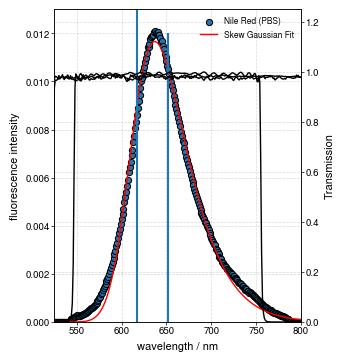

In [35]:
fig, axs = plotter.one_column_plot()

axs = plotter.scatter_plot(axs, x=wavelength, y=dye_spectrum.T, ylabel='fluorescence intensity', xlabel='wavelength / nm', 
                           label='Nile Red (PBS)', facecolor=None)
axs = plotter.line_plot(axs, x=wavelength, y=fitted_spectrum, ylabel='fluorescence intensity', xlabel='wavelength / nm', color='red',
                       label='Skew Gaussian Fit')
axs.vlines(S_F.wavelength_to_energy(result.x[1]), ymin=0, ymax=0.013)

ax2 = axs.twinx()
ax2 = plotter.line_plot(ax2, x=wavelength, y=filter_spectra.T, ylabel='Transmission')
ax2.set_ylim([0, 1.25])
axs.vlines(ymin=0, ymax=0.012, x=wavelength_mean)

axs.set_xlim([525, 800])
ax2.set_xlim([525, 800])
axs.set_ylim([0, 0.013])
axs.legend(loc='best', frameon=False, fontsize=6)
#folder = '/home/jbeckwith/Documents/pCloud/Chemistry/Lee/Papers/Multicolour/SI/Nile_Red_Forward_Model/'
plt.show()
#plt.savefig(os.path.join(folder, 'Fit_Fluo_Spectrum.svg'), dpi=600, format='svg')

In [36]:
svalues = np.array([560, 570, 580, 590, 600, 610, 620, 630, 640, 650, 660])
len(svalues)

11

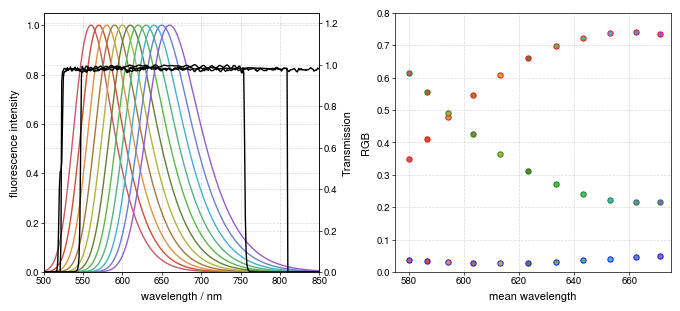

In [37]:
fig, axs = plotter.two_column_plot(ncols=2, width_ratios=[1,1])
colours = ["#c6596a",
"#ca5137",
"#e09343",
"#a2783e",
"#b3b343",
"#637f37",
"#5bb74c",
"#57b183",
"#45b0cf",
"#6c80cc",
"#935ecb",
"#c076b0",
"#cc4497"]

svalues = np.array([560, 570, 580, 590, 600, 610, 620, 630, 640, 650, 660])
for i, s in enumerate(svalues):
    # s is the desired PEAK wavelength of the rendered spectrum -- generate_nile_red_spectrum's
    # own `wavelength_center` argument is a location parameter, not the peak (the two differ
    # by tens of nm; see wavelength_center_for_peak's docstring), so convert first.
    wavelength_center = NR_F.wavelength_center_for_peak(s, wavelength)
    spectrum = NR_F.generate_nile_red_spectrum(
                wavelength_center, wavelength, normalize=True
            )
    spectrum_filtered = NR_F.apply_optical_filters(spectrum, filter_spectra)
    rgb = NR_F.calculate_rgb_from_spectrum(
            spectrum_filtered, wavelength, pixel_QYs
        )
    denom = np.trapz(spectrum_filtered, wavelength)
    wavelength_mean = np.trapz(spectrum_filtered * wavelength, wavelength) / denom

    axs[0] = plotter.line_plot(axs[0], x=wavelength, y=spectrum/np.max(spectrum), 
                               ylabel='fluorescence intensity', xlabel='wavelength / nm', color=colours[i],)

    axs[1] = plotter.scatter_plot(axs[1], x=wavelength_mean, y=rgb[0], facecolor=colours[i], xlabel='mean wavelength', edgecolor='red',
                                 ylabel='RGB', linewidth=0.6, size=15)
    axs[1] = plotter.scatter_plot(axs[1], x=wavelength_mean, y=rgb[1], facecolor=colours[i], xlabel='mean wavelength', edgecolor='green',
                                 ylabel='RGB', linewidth=0.6, size=15)
    axs[1] = plotter.scatter_plot(axs[1], x=wavelength_mean, y=rgb[2], facecolor=colours[i], xlabel='mean wavelength', edgecolor='blue',
                                 ylabel='RGB', linewidth=0.6, size=15)

axs[0].set_xlim([500, 850])
ax2 = axs[0].twinx()
ax2 = plotter.line_plot(ax2, x=wavelength, y=filter_spectra.T, ylabel='Transmission')
ax2.set_ylim([0, 1.25])
ax2.set_xlim([500, 850])

axs[0].set_ylim([0, 1.05])
axs[1].set_xlim([575, 675])
axs[1].set_ylim([0.0, 0.8])

folder = '/home/jbeckwith/Documents/Chemistry/Lee/Papers/Multicolour/SI/Nile_Red_Forward_Model/'
#plt.savefig(os.path.join(folder, 'Example_Propagation_Figure.svg'), dpi=600, format='svg')
plt.show()

In [38]:
from pyS3M import NileRedFunctions

NR_F = NileRedFunctions.NileRed_Functions()

save_folder = "/home/jbeckwith/Documents/Chemistry/Lee/Data/Simulation/20260724_NileRedModelTesting"

# Photon range updated to match real Nile Red / NR4A exemplar data (NR/Localisations.h5,
# NR4A/Localisations.h5, and the SAureus NR4A titration): the bulk of real, QC'd
# localisations fall between ~100 and ~30,000 photons (1st-99th percentile across
# datasets), vs. the previous 500-20000 range. Lower bound set to 200 (not the raw
# ~100 floor) to match real analysis practice, which routinely excludes fits below
# 200 photons.
n_photon_space = np.logspace(np.log10(200), np.log10(10000), 25)

# Background likewise updated: real per-localisation background_photons (bg_B+bg_G+bg_R)
# medians ~35-45 for Nile Red, ~45-70 for NR4A/SAureus -- swept as three representative
# levels (previously a single, unrealistically low flat 5.0) rather than one flat value.
background_levels = [20.0, 45.0, 70.0]  # NR-like low / typical / NR4A-SAureus-like high


In [20]:
for background_photons in background_levels:
    NR_F.simulate_wavelength_precision(
          save_folder=save_folder,
          wavelength_range=(560, 660),
          wavelength_step=5,
          photon_counts=n_photon_space,
          filter_names=filters,
          n_bootstrap=10000,
          image_size = 16,
          background_photons=background_photons,
          camera_parameters=camera_parameters,
          starting_flag=f"bg{int(background_photons)}_",
          verbose=False,
          use_tqdm=False,
      )

INFO:pyS3M.simulation.multicolour:Overwrite=True: Deleting existing results file: bg20_wl560_LM_method_simulated_NileRed_560nm_rawresults.h5
Process ForkProcess-46:
Process ForkProcess-39:
Process ForkProcess-50:
Process ForkProcess-54:
Process ForkProcess-42:
Process ForkProcess-43:
Process ForkProcess-38:
Process ForkProcess-41:
Traceback (most recent call last):


KeyboardInterrupt: 

  File "/usr/lib/python3.12/multiprocessing/process.py", line 314, in _bootstrap
    self.run()
  File "/usr/lib/python3.12/multiprocessing/process.py", line 108, in run
    self._target(*self._args, **self._kwargs)
  File "/usr/lib/python3.12/concurrent/futures/process.py", line 251, in _process_worker
    call_item = call_queue.get(block=True)
                ^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/queues.py", line 103, in get
    res = self._recv_bytes()
          ^^^^^^^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/connection.py", line 216, in recv_bytes
    buf = self._recv_bytes(maxlength)
          ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/connection.py", line 430, in _recv_bytes
    buf = self._recv(4)
          ^^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/connection.py", line 395, in _recv
    chunk = read(handle, remaining)
            ^^^^^^^^^^^^^^^^^^^^^^^
KeyboardInterrupt
Traceback (most 

In [39]:
# One summary CSV per background level (starting_flag=f"bg{int(background_photons)}_"),
# all in the same save_folder -- load and concatenate, tagging each with its background level.
# NOTE: these are the ORIGINAL summary CSVs, computed by simulate_wavelength_precision's
# own (buggy, pre-fix) Stage 2 -- kept here only for reference/comparison. The corrected
# `data` used by the plots below is computed fresh from the raw per-localisation results
# in the next cell, NOT from these CSVs.
data_frames = []
for background_photons in background_levels:
    file = f"bg{int(background_photons)}_wavelength_precision_summary.csv"
    df_bg = pd.read_csv(os.path.join(save_folder, file))
    df_bg["background_photons"] = background_photons
    data_frames.append(df_bg)
data_original = pd.concat(data_frames, ignore_index=True)

## Reprocessing the main sweep with the NaN-safe wavelength fit

`_add_nile_red_wavelength_fits` (`simulation/multicolour.py`) had a bug: its guard for
skipping a failed colour fit was `if rgb_total[j] <= 0: continue`, and `NaN <= 0` is
`False` in Python/NumPy -- so localisations whose colour fit itself failed (`A_R`/`A_G`/
`A_B` all `NaN`) were **not** skipped, and were fed straight into
`fit_nile_red_wavelength`, which doesn't detect `NaN` input either and silently returns a
spurious, deterministic "fit" (near-zero reported error) instead of failing. That fake
value got written into `wl_fit` as if it were a real per-sample estimate, and contaminated
every downstream bias/precision statistic -- worst at low photon counts, where a large
fraction of colour fits genuinely fail (measured at 55.8% of bootstraps in the bg20/560nm/
100-photon bin alone, from the original 100-photon-floor sweep -- the floor is now 200,
see below).

This is now fixed at the source, but the existing raw results in `save_folder` predate the
fix. No re-simulation is needed to correct them, though: the bug only ever affected rows
whose colour fit had already failed (`A_R` is `NaN`) -- rows with a valid colour fit went
through the normal (unaffected) code path, so their existing `wl_fit` is already correct.
Reprocessing is therefore just: drop the failed-colour-fit rows from each existing
`rawresults.h5`, then recompute `wavelength_bias`/`wavelength_precision`/`recovery_rate`
from the remaining (already-correct) `wl_fit` values -- no refitting required.

This cell defines `data` (used by every plot/analysis cell below), computed fresh from
the raw per-localisation results -- **not** from the `data_original` DataFrame loaded in
the cell just above (which reflects the original, pre-fix summary CSVs and is kept only
for reference/comparison).

In [40]:
import re

# Reprocess every existing rawresults.h5 under save_folder: drop rows whose colour fit
# failed (NaN A_R -- these previously carried the spurious fixed-point wl_fit described
# above) and recompute the summary statistics from the remaining valid wl_fit values.
# Original (buggy) summary CSVs are left untouched on disk; corrected ones are written
# with a "_reprocessed" suffix.

# Fresh wavelength_array from setup_optical_system (not the notebook's own `wavelength`
# global), matching exactly what simulate_wavelength_precision used internally to compute
# its wl_true_com reference -- see cell 19's identical rationale for the pixellation test.
wavelength_array_reproc, _, _ = NR_F.setup_optical_system(filters)

reprocessed_records = []

# Discover which (background, true-wavelength) combinations were actually
# simulated by scanning filenames on disk directly -- self-contained, doesn't
# depend on `true_wavelengths`/`data` from any other cell.
raw_result_files = sorted(Path(save_folder).glob("bg*_wl*_*_rawresults.h5"))
name_pattern = re.compile(r"^bg(?P<bg>\d+)_wl(?P<wl>\d+)_")

files_by_bg_wl = {}
for p in raw_result_files:
    m = name_pattern.match(p.name)
    if not m:
        continue
    files_by_bg_wl.setdefault((float(m.group("bg")), float(m.group("wl"))), []).append(p)

for (background_photons, wl_true), raw_files in sorted(files_by_bg_wl.items()):

        # Same truth reference simulate_wavelength_precision's Stage 2 uses: convert the
        # true PEAK wavelength to the location parameter that actually renders a spectrum
        # peaking there, then take that location parameter's raw-spectrum centre of mass.
        wavelength_center_true = NR_F.wavelength_center_for_peak(wl_true, wavelength_array_reproc)
        wl_true_com = NR_F.spectral_centre_of_mass(wavelength_center_true, wavelength_array_reproc)

        for raw_file in raw_files:
            df_raw = IO.read_h5_database(str(raw_file))

            for level in sorted(df_raw["photon_level"].unique()):
                df_level = df_raw[df_raw["photon_level"] == level]
                n_bootstrap_level = len(df_level)

                # Drop failed colour fits (previously: spurious fixed-point wl_fit).
                df_valid = df_level[df_level["A_R"].notna()]

                wavelengths_fitted = df_valid["wl_fit"].dropna().to_numpy()
                if len(wavelengths_fitted) == 0:
                    continue

                reprocessed_records.append({
                    "wavelength_true": wl_true,
                    "background_photons": background_photons,
                    "photon_level": int(level),
                    "n_photons": df_valid["photons"].mean(),
                    "wavelength_precision": np.std(wavelengths_fitted),
                    "wavelength_bias": np.mean(wavelengths_fitted) - wl_true_com,
                    "wavelength_mean": np.mean(wavelengths_fitted),
                    "recovery_rate": len(wavelengths_fitted) / n_bootstrap_level,
                    "n_successful": len(wavelengths_fitted),
                    "n_failed_colour_fit": n_bootstrap_level - len(df_valid),
                })

data = pd.DataFrame(reprocessed_records)

for background_photons in background_levels:
    sub = data[data["background_photons"] == background_photons]
    out_path = os.path.join(save_folder, f"bg{int(background_photons)}_wavelength_precision_summary_reprocessed.csv")
    sub.drop(columns=["background_photons"]).to_csv(out_path, index=False)
    print(f"Wrote {out_path} ({len(sub)} rows)")

data

Wrote /home/jbeckwith/Documents/Chemistry/Lee/Data/Simulation/20260724_NileRedModelTesting/bg20_wavelength_precision_summary_reprocessed.csv (500 rows)
Wrote /home/jbeckwith/Documents/Chemistry/Lee/Data/Simulation/20260724_NileRedModelTesting/bg45_wavelength_precision_summary_reprocessed.csv (525 rows)
Wrote /home/jbeckwith/Documents/Chemistry/Lee/Data/Simulation/20260724_NileRedModelTesting/bg70_wavelength_precision_summary_reprocessed.csv (525 rows)


,wavelength_true,background_photons,photon_level,n_photons,wavelength_precision,wavelength_bias,wavelength_mean,recovery_rate,n_successful,n_failed_colour_fit
0,565.0,20.0,0,220.634232,83.826249,27.064151,603.565445,0.6884,6884,3116
1,565.0,20.0,1,233.693726,67.217971,12.861623,589.362917,0.7195,7195,2805
2,565.0,20.0,2,255.581955,48.588277,2.434872,578.936166,0.7617,7617,2383
3,565.0,20.0,3,287.456024,29.842176,-4.507374,571.993921,0.7854,7854,2146
4,565.0,20.0,4,329.789551,23.402617,-5.442723,571.058571,0.8145,8145,1855
...,...,...,...,...,...,...,...,...,...,...
1545,660.0,70.0,20,3663.538086,15.721067,-0.822569,675.424018,0.9995,9995,5
1546,660.0,70.0,21,4303.612305,14.355787,-0.527412,675.719175,0.9998,9998,2
1547,660.0,70.0,22,5063.114746,13.397732,-0.173020,676.073566,1.0000,10000,0
1548,660.0,70.0,23,5950.379395,12.314738,-0.239693,676.006893,1.0000,10000,0


In [41]:
true_wavelengths = np.unique(data['wavelength_true'].to_numpy())

In [42]:
data['wavelength_true']

0       565.0
1       565.0
2       565.0
3       565.0
4       565.0
        ...  
1545    660.0
1546    660.0
1547    660.0
1548    660.0
1549    660.0
Name: wavelength_true, Length: 1550, dtype: float64

INFO:pyS3M.PlottingBase:Plot saved to: /home/jbeckwith/Documents/Chemistry/Lee/Papers/Multicolour/SI/Nile_Red_Forward_Model/Forward_Model_Validation_surface_wavelength_precision.svg


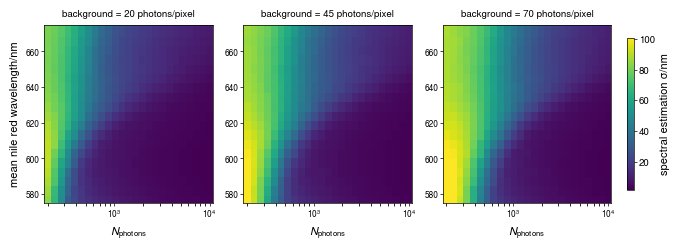

Saved Forward_Model_Validation_surface_wavelength_precision.svg


INFO:pyS3M.PlottingBase:Plot saved to: /home/jbeckwith/Documents/Chemistry/Lee/Papers/Multicolour/SI/Nile_Red_Forward_Model/Forward_Model_Validation_surface_wavelength_bias.svg


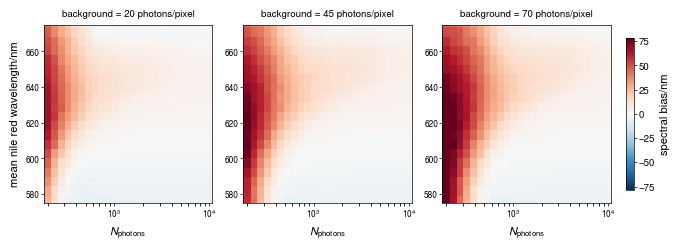

Saved Forward_Model_Validation_surface_wavelength_bias.svg


In [44]:
import matplotlib.colors as mcolors

folder = '/home/jbeckwith/Documents/Chemistry/Lee/Papers/Multicolour/SI/Nile_Red_Forward_Model/'
fs = plotter.config.font_size

# Surface plots (matching Figure1_SBR.ipynb's style): rows = metric (one figure each),
# cols = background level. x = N_photons (log, aligned to n_photon_space via
# photon_level's index -- the fitted mean `n_photons` varies slightly by wavelength at
# the same nominal level, so it isn't a clean shared grid coordinate), y = true
# wavelength, colour = the metric.
metric_info = [
    ('wavelength_precision', 'spectral estimation σ/nm', 'viridis'),
    ('wavelength_bias', 'spectral bias/nm', 'RdBu_r'),
]

n_levels = len(n_photon_space)

# true_wavelengths holds true PEAK wavelengths; the y-axis below instead uses the MEAN
# (spectral centre-of-mass) wavelength -- same conversion cell 15's reprocessing step
# uses for its wl_true_com reference. wavelength_array_reproc comes from that cell
# (NR_F.setup_optical_system(filters)), which runs before this one.
true_wavelengths_com = np.array([
    NR_F.spectral_centre_of_mass(
        NR_F.wavelength_center_for_peak(wl, wavelength_array_reproc), wavelength_array_reproc,
    )
    for wl in true_wavelengths
])

for metric, cbar_lbl, cmap in metric_info:
    # Build a (background, wavelength, photon_level) grid for this metric.
    Z_all = np.full((len(background_levels), len(true_wavelengths), n_levels), np.nan)
    for i_bg, bg in enumerate(background_levels):
        data_bg = data[data['background_photons'] == bg]
        for i_wl, wl in enumerate(true_wavelengths):
            sub = data_bg[data_bg['wavelength_true'] == wl]
            for _, row in sub.iterrows():
                Z_all[i_bg, i_wl, int(row['photon_level'])] = row[metric]

    if metric == 'wavelength_bias':
        # Diverging, centred on zero -- bias can be positive or negative.
        vmax = float(np.nanpercentile(np.abs(Z_all), 99))
        norm = mcolors.TwoSlopeNorm(vcenter=0.0, vmin=-vmax, vmax=vmax)
    else:
        vmin = float(np.nanmin(Z_all))
        vmax = float(np.nanpercentile(Z_all, 99))
        norm = mcolors.Normalize(vmin=vmin, vmax=vmax)

    fig, axs = plt.subplots(
        nrows=1, ncols=len(background_levels), figsize=(6.69, 2.4), squeeze=False,
    )
    for i_bg, bg in enumerate(background_levels):
        ax = axs[0, i_bg]
        Z = Z_all[i_bg]  # (n_wavelength, n_photon_levels)
        # rasterized=True embeds the mesh as a bitmap in the saved SVG instead of
        # per-quad vector polygons -- avoids thin gray/white seams between adjacent
        # pcolormesh cells on vector export (see Figure1_SBR.ipynb's identical note).
        ax.pcolormesh(
            n_photon_space, true_wavelengths_com, Z,
            cmap=cmap, shading='auto', norm=norm, rasterized=True,
        )
        ax.set_xscale('log')
        ax.set_xlabel(r'$N_{\rm photons}$', fontsize=fs + 1)
        ax.set_ylabel('mean nile red wavelength/nm' if i_bg == 0 else '', fontsize=fs + 1)
        ax.set_title(f'background = {int(bg)} photons/pixel', fontsize=fs)
        ax.tick_params(labelsize=fs - 1)
        ax.set_ylim([575, 675])

    fig.colorbar(
        plt.cm.ScalarMappable(norm=norm, cmap=cmap),
        ax=axs, label=cbar_lbl, shrink=0.85, aspect=20, pad=0.02,
    )
    fname = f'Forward_Model_Validation_surface_{metric}.svg'
    plotter.save_or_show(fig, save_path=os.path.join(folder, fname), show=True, dpi=600)
    print(f'Saved {fname}')

## Does pixellating localisations before fitting reduce bias?

Real Nile Red/NR4A analysis (`NileRedFunctions.fit_wavelengths_pixelated`) spatially bins
many localisations and fits one wavelength per bin, rather than fitting every
localisation individually -- on the assumption that pooling improves things. That
assumption has never been checked against known ground truth. Here we simulate
`N_BOOTSTRAP_PT` independent localisations at a single known true wavelength, photon
level and background, then compare three ways of turning them into a wavelength
estimate:

- **(a) Individual** (`k=1`) -- fit each localisation's own wavelength independently
  (the existing per-bootstrap `wl_fit`, unbinned) -- current production behaviour.
- **(b) Pixellated/pooled** (`k>1`) -- group localisations into batches of `k` and combine
  each group the same way the real pipeline combines localisations for pixellated data
  (`NileRedFunctions.fit_wavelengths_pixelated`'s per-pixel binning): an inverse-error-
  weighted average of each localisation's own already-fitted `A_R`/`A_G`/`A_B`/`s_x`/`s_y`
  (`_weighted_average_with_error`), RGB-renormalised with error propagation
  (`_normalize_rgb_with_errors`), then fit **once** per group. (An earlier version of this
  test instead reconstructed and summed raw amplitude-times-photons counts across the
  group -- a different operation that isn't what the real pipeline does, and that let
  each low-photon localisation's own colour-fit bias carry through into the pooled
  estimate with equal weight regardless of its individual precision.)
- **(c) Equal-photon-budget control** -- a separate simulation at
  `n_photon = k * photon_level`, i.e. the same total photon budget as (b) achieved in one
  shot rather than pooled -- checked as a sanity check on the grouping code, and to see
  whether pooling many dim localisations is as good as one bright one.

`photon_level` sweeps `PHOTON_LEVELS_PT` (representative per-localisation photon counts
from the updated real-data range above); `k` sweeps `K_VALUES_PT` (realistic render-pixel
occupancy, matching the "~25 locs/pixel" figure already used for the real 50 nm
pixellated fit). Background is fixed at a representative `BACKGROUND_PT` and true
wavelength at `WL_TRUE_PT` to keep this exploratory grid a manageable size -- the sweep
above already covers the full wavelength/background range for the unbinned baseline.

In [38]:
# Fresh wavelength_array/pixel_QYs/filter_spectra from setup_optical_system, rather than
# reusing the notebook's `wavelength` global -- the validation-figure cell above runs
# `for wavelength in true_wavelengths:`, which overwrites `wavelength` (originally the
# spectral wavelength grid) with a scalar. Distinct names here avoid that collision.
wavelength_array, pixel_QYs_pt, filter_spectra_pt = NR_F.setup_optical_system(filters)

pixel_pt_size = 69.0  # nm
NA_pt = 1.49
WL_TRUE_PT = 600.0     # representative true PEAK wavelength for this test
BACKGROUND_PT = 45.0   # representative background (median across real NR/NR4A datasets)
# N_BOOTSTRAP_PT increased from 3000 -> 20000: reaching photon_level_max * k = 2e7
# needs k=2000 (since PHOTON_LEVELS_PT tops out at 10000/localisation), and
# fit_pixelated_groups needs N_BOOTSTRAP_PT // k independent groups to pool. (1e8 was
# tried first -- it needs k=10000, which would need N_BOOTSTRAP_PT>=50000 for even a
# thin 5 groups at that k, a 16.7x cost increase; dialed back to 2e7/k=2000, which
# only needs this more modest 6.7x increase for a healthier 10 groups at the top end.)
N_BOOTSTRAP_PT = 20000
PHOTON_LEVELS_PT = np.array([200.0, 300.0, 1000.0, 3000.0, 10000.0])  # per-localisation
# Extended to reach photon_level_max * k = 2e7 (10000 * 2000), spanning the full
# measured real-data range of ~1e4-1e7 photons/pixel with margin either side.
K_VALUES_PT = [1, 5, 10, 25, 50, 100, 250, 500, 1000, 2000]

pixellation_save_folder = "/home/jbeckwith/Documents/Chemistry/Lee/Data/Simulation/20260724_NileRed_PixellationTest"
os.makedirs(pixellation_save_folder, exist_ok=True)

# WL_TRUE_PT is the desired PEAK wavelength, not generate_nile_red_spectrum's own
# location-parameter argument (the two differ by tens of nm -- see
# wavelength_center_for_peak's docstring) -- convert before generating, so
# spectrum_pt (what get_localisation_batch actually simulates images from) really
# peaks at WL_TRUE_PT.
WAVELENGTH_CENTER_PT = NR_F.wavelength_center_for_peak(WL_TRUE_PT, wavelength_array)
spectrum_pt = NR_F.generate_nile_red_spectrum(WAVELENGTH_CENTER_PT, wavelength_array, normalize=True)

# fit_nile_red_wavelength returns the raw (un-filtered) spectrum's centre of mass,
# evaluated at whatever location parameter the LSQ fit recovers -- compare bias
# against that *same* quantity computed at the true location parameter
# (WAVELENGTH_CENTER_PT), not against WL_TRUE_PT directly (which would reintroduce
# the ~20 nm peak-vs-mean gap as spurious bias) and not against
# spectral_centre_of_mass(WL_TRUE_PT, ...) either (WL_TRUE_PT is a peak, not a
# location parameter, so that would be a different, additional error again).
WL_TRUE_COM_PT = NR_F.spectral_centre_of_mass(WAVELENGTH_CENTER_PT, wavelength_array)
print(f"WL_TRUE_PT (peak) = {WL_TRUE_PT:.2f} nm; "
      f"location parameter = {WAVELENGTH_CENTER_PT:.2f} nm; "
      f"true spectral centre of mass = {WL_TRUE_COM_PT:.2f} nm")

WL_TRUE_PT (peak) = 600.00 nm; location parameter = 582.53 nm; true spectral centre of mass = 613.14 nm


In [14]:
def get_localisation_batch(photon_level, flag_suffix):
    """Simulate N_BOOTSTRAP_PT independent localisations at WL_TRUE_PT/BACKGROUND_PT/
    photon_level (via the same test_fit_method/_add_nile_red_wavelength_fits machinery
    the main sweep above uses), returning the raw per-localisation fit DataFrame
    (A_R/A_G/A_B/s_x/s_y/photons/background_photons + individual wl_fit)."""
    config = Multicolour_Simulation_Functions.SimulationConfig(
        n_bootstrap=N_BOOTSTRAP_PT,
        background_photons=BACKGROUND_PT,
        NA=NA_pt,
        pixel_size=pixel_pt_size,
        cpu_fraction=0.9,
        save_raw_results=True,
        subtractx0y0=False,
        saverawimages=False,
    )
    flag = f"pixtest_{flag_suffix}_"
    dyestr = f"simulated_NileRed_{int(WL_TRUE_PT)}nm"

    MSF.test_fit_method(
        dye=dyestr,
        filters=filters,
        wavelength=wavelength_array,
        camera_parameters=camera_parameters,
        save_folder=pixellation_save_folder,
        n_photon_space=np.array([photon_level]),
        smoothing_function=smoothing_function,
        starting_flag=flag,
        config=config,
        single_dye_spectrum=spectrum_pt,
        nile_red_wavelength=WL_TRUE_PT,
    )

    raw_files = list(Path(pixellation_save_folder).glob(f"{flag}*rawresults.h5"))
    return IO.read_h5_database(str(raw_files[0]))

In [15]:
def combine_group(df_group):
    """Combine a group of independent localisations into one pixel-level observation
    using the SAME method the real pipeline uses for pixellated data
    (NileRedFunctions.fit_wavelengths_pixelated's per-pixel binning): an inverse-error-
    weighted average of each localisation's own already-fitted A_R/A_G/A_B/s_x/s_y
    (NR_F._weighted_average_with_error, weights = 1/error), then RGB-renormalise with
    error propagation (NR_F._normalize_rgb_with_errors) -- not a sum of amplitude-times-
    photons reconstructed raw counts (a different operation, and not what the real code
    does). photons/background_photons are still summed across the group, but only for
    the SNR-based error-inflation term inside fit_nile_red_wavelength, not to rebuild
    amplitudes."""
    avg_R, avg_R_err = NR_F._weighted_average_with_error(
        df_group['A_R'].to_numpy(), df_group['A_R_err'].to_numpy())
    avg_G, avg_G_err = NR_F._weighted_average_with_error(
        df_group['A_G'].to_numpy(), df_group['A_G_err'].to_numpy())
    avg_B, avg_B_err = NR_F._weighted_average_with_error(
        df_group['A_B'].to_numpy(), df_group['A_B_err'].to_numpy())
    avg_sx, avg_sx_err = NR_F._weighted_average_with_error(
        df_group['s_x'].to_numpy(), df_group['s_x_err'].to_numpy())
    avg_sy, avg_sy_err = NR_F._weighted_average_with_error(
        df_group['s_y'].to_numpy(), df_group['s_y_err'].to_numpy())

    sigma_x_group = avg_sx * pixel_pt_size
    sigma_y_group = avg_sy * pixel_pt_size
    sigma_x_err_group = avg_sx_err * pixel_pt_size
    sigma_y_err_group = avg_sy_err * pixel_pt_size

    rgb = np.array([avg_R, avg_G, avg_B])
    rgb_err = np.array([avg_R_err, avg_G_err, avg_B_err])
    rgb_norm, rgb_norm_err = NR_F._normalize_rgb_with_errors(rgb, rgb_err)

    total_photons = float(df_group['photons'].to_numpy().sum())
    background_photons_group = float(df_group['background_photons'].to_numpy().sum())

    return (
        rgb_norm, rgb_norm_err, sigma_x_group, sigma_y_group,
        sigma_x_err_group, sigma_y_err_group, total_photons, background_photons_group,
    )

import types

smoothing_function = types.SimpleNamespace()
smoothing_function.args = {"sigma": 1.5}
smoothing_function.extent = 1.5
smoothing_function.smoothing_function = sCMOS.gaussian_filter_stack
smoothing_function.data_arg = "image"

def fit_pixelated_groups(df, k, shuffle=False):
    """Split df into non-overlapping groups of size k, combine each group via
    combine_group (matching the real per-pixel binning method), and fit one wavelength
    per group. shuffle=True randomises row order first -- needed when df is a pool of
    several concatenated photon levels, so each group is a genuine random mix rather
    than (near-)homogeneous consecutive blocks from the concatenation order.

    Returns (wl_pixel, total_photons_pixel): both length n_groups, NaN where a group's
    combine/fit failed or was skipped."""
    if shuffle:
        df = df.sample(frac=1.0).reset_index(drop=True)
    n_groups = len(df) // k
    df_trim = df.iloc[: n_groups * k]
    wl_pixel = np.full(n_groups, np.nan)
    total_photons_pixel = np.full(n_groups, np.nan)

    for g in range(n_groups):
        group = df_trim.iloc[g * k: (g + 1) * k]
        try:
            rgb_norm, rgb_norm_err, sx, sy, sx_err, sy_err, tot_photons, tot_bg = combine_group(group)
        except (ZeroDivisionError, ValueError):
            continue
        # NaN <= 0 is False, so a plain `<= 0` check silently lets a NaN-contaminated
        # group average (from a failed individual colour fit pooled into this group)
        # through into fit_nile_red_wavelength, which doesn't detect NaN input either
        # and returns a spurious, deterministic "fit" (near-zero reported error) instead
        # of failing. Explicitly require finite as well as positive.
        if not np.all(np.isfinite(rgb_norm)) or np.any(rgb_norm <= 0):
            continue
        wl, _ = NR_F.fit_nile_red_wavelength(
            observed_rgb=rgb_norm, observed_sigma_x=sx, observed_sigma_y=sy,
            rgb_errors=rgb_norm_err, sigma_x_error=sx_err, sigma_y_error=sy_err,
            filter_spectra=filter_spectra_pt, wavelength_array=wavelength_array,
            pixel_QYs=pixel_QYs_pt, NA=NA_pt, total_photons=tot_photons,
            background_photons=tot_bg,
        )
        wl_pixel[g] = wl
        total_photons_pixel[g] = tot_photons

    return wl_pixel, total_photons_pixel

In [ ]:
results_records = []

for photon_level in PHOTON_LEVELS_PT:
    df = get_localisation_batch(photon_level, flag_suffix=f"p{int(photon_level)}")

    # Drop localisations whose colour fit failed (NaN A_R/A_G/A_B) before doing
    # anything else -- these would never reach wavelength-fitting in the real
    # analysis pipeline (_add_nile_red_wavelength_fits skips them, now NaN-safe).
    # Previously these survived here with a fixed-point wl_fit value (the NaN
    # input silently produces a spurious, deterministic "fit" rather than NaN),
    # which corrupted both the individual (k=1) stats and the pooled photon sums
    # -- explaining the ~1e-13 "precision" once enough groups became NaN-dominated.
    n_before = len(df)
    df = df[df['A_R'].notna()].reset_index(drop=True)
    print(f"photon_level={photon_level}: dropped {n_before - len(df)}/{n_before} failed colour fits before fitting")

    for k in K_VALUES_PT:
        if k == 1:
            # (a) individual fits -- already computed per-localisation by
            # _add_nile_red_wavelength_fits inside test_fit_method, no pooling.
            wl_values = df['wl_fit'].to_numpy()
        else:
            # (b) pixellated/pooled fits.
            wl_values, _ = fit_pixelated_groups(df, k)
        wl_values = wl_values[~np.isnan(wl_values)]
        if len(wl_values) == 0:
            continue
        results_records.append({
            'photon_level': photon_level,
            'k': k,
            'bias': np.mean(wl_values) - WL_TRUE_COM_PT,
            'precision': np.std(wl_values),
            'n_groups': len(wl_values),
        })

pixellation_results = pd.DataFrame(results_records)
pixellation_results.to_csv(os.path.join(pixellation_save_folder, 'pixellation_bias_precision.csv'), index=False)
pixellation_results

In [ ]:
# Sanity check (c): equal-photon-budget control. Fits n_photon = k*photon_level in one
# shot (no pooling) at a fixed check k (below), for the smallest and largest per-localisation
# photon levels -- should roughly match the pixellated (b) bias/precision at the same
# (photon_level, k), confirming the grouping/summing code above isn't silently wrong.
control_records = []
# Deliberately NOT K_VALUES_PT[-1] (now 2000): this control's cost is one
# get_localisation_batch call per photon_level at n_photon = photon_level * k_check,
# so following K_VALUES_PT's max here would mean simulating N_BOOTSTRAP_PT
# localisations at up to photon_level_max * 2000 = 2e7 photons each, purely as a
# sanity check. k_check=50 (the original ceiling before this section's k-range was
# extended) already validates the grouping/summing code without that blow-up.
k_check = 50
for photon_level in [PHOTON_LEVELS_PT[0], PHOTON_LEVELS_PT[-1]]:
    df_control = get_localisation_batch(photon_level * k_check, flag_suffix=f"control_p{int(photon_level)}_k{k_check}")
    wl_control = df_control['wl_fit'].to_numpy()
    wl_control = wl_control[~np.isnan(wl_control)]
    control_records.append({
        'photon_level': photon_level, 'k': k_check,
        'equivalent_total_photons': photon_level * k_check,
        'bias': np.mean(wl_control) - WL_TRUE_COM_PT,
        'precision': np.std(wl_control),
    })

control_df = pd.DataFrame(control_records)
print("Equal-photon-budget control (c):")
print(control_df)
print("\nPixellated (b) at the same (photon_level, k) for comparison:")
print(pixellation_results[
    (pixellation_results['k'] == k_check)
    & (pixellation_results['photon_level'].isin([PHOTON_LEVELS_PT[0], PHOTON_LEVELS_PT[-1]]))
])

In [ ]:
fig, axs = plotter.two_column_plot(ncols=2, width_ratios=[1, 1])

# Generated (not hardcoded) so this always covers K_VALUES_PT regardless of length --
# it previously only had entries for the original 5 k values.
k_colours = dict(zip(K_VALUES_PT, plt.cm.viridis(np.linspace(0, 1, len(K_VALUES_PT)))))

# Real pixellated render data accumulates ~1e4-1e7 photons per render pixel -- plot
# against that (photon_level * k, the total pooled budget landing in one pixel) rather
# than photons per individual localisation, and highlight that measured range.
REAL_PHOTONS_PER_PIXEL_RANGE = (1e4, 1e7)

for k in K_VALUES_PT:
    subset = pixellation_results[pixellation_results['k'] == k].sort_values('photon_level')
    if len(subset) == 0:
        continue
    photons_per_pixel = subset['photon_level'] * k
    axs[0] = plotter.line_plot(
        axs[0], photons_per_pixel, subset['precision'],
        label=f'k={k}', color=k_colours[k],
        xlabel=r'$N_{\rm photons}$ per pixel',
        ylabel='wavelength precision (σ) / nm',
    )
    axs[1] = plotter.line_plot(
        axs[1], photons_per_pixel, subset['bias'],
        label=f'k={k}', color=k_colours[k],
        xlabel=r'$N_{\rm photons}$ per pixel',
        ylabel='wavelength bias / nm',
    )

for i, ax in enumerate(axs):
    ax.axvspan(
        *REAL_PHOTONS_PER_PIXEL_RANGE, color='0.5', alpha=0.15, zorder=0,
        label='measured range (real data)' if i == 1 else None,
    )

axs[0].set_xscale('log')
axs[0].set_yscale('log')
axs[1].set_xscale('log')
axs[1].set_yscale('log')
axs[1].axhline(0.0, color='k', lw=0.6, ls='--')
axs[1].legend(loc='best', fontsize=6)

fig.suptitle(
    f'Pixellation test: true wavelength={WL_TRUE_PT:.0f} nm, background={BACKGROUND_PT:.0f} photons/pixel',
    fontsize=8,
)

folder_pt = '/home/jbeckwith/Documents/Chemistry/Lee/Papers/Multicolour/SI/Nile_Red_Forward_Model/'
plt.savefig(os.path.join(folder_pt, 'Pixellation_Bias_Precision.svg'), dpi=600, format='svg')
plt.show()

## Precision/bias surfaces across wavelength and total post-pixellation photons

Adaptive Monte Carlo, targeting each bin directly (see the two design notes below for
why this replaced two earlier, less effective versions).

**Design note 1 (blind rejection sampling -> per-bin targeting):** an earlier version
drew `(k, photons)` from their natural marginal distributions and only checked
afterwards which bin -- if any -- usefully absorbed the result; most attempts landed in
whichever bins were already full, wasting the (expensive) simulate+combine+fit call on
discarded results (one real run needed 932,992 attempts in 3600s to fill just 31/50 bins
for a single wavelength). Fixed by looping bin-by-bin (each with its own attempt/time
budget) and drawing `k`/photons *targeted* at the current bin.

**Design note 2 (k_min/k_max ceilings relaxed):** `k` (localisations combined per
rendered pixel) is grounded in the real empirical distribution of 239,400 real occupied
50nm pixels from
`/media/jbeckwith/Ezra Seagat/NileRed_ExemplarData/NR4A/Localisations_undrifted_locs.h5`
(`NR4A_pixel_occupancy_k_distribution.npy`) -- but that one finite real sample only spans
k=1-2426, which can't reach every bin on its own: the lowest bins need k as low as 1 (fine,
already within range) but the *highest* bins need k up into the thousands-to-tens-of-
thousands given `PHOTON_RANGE_PT`'s 10,000-photon ceiling, well beyond the empirical max.
Rather than being capped there, `draw_k_for_bin` prefers real bootstrapped values when
they can feasibly reach the current bin, and extends beyond the empirical max using a
power-law tail fitted to the real distribution's own upper range (k=100-2000, where a
clean power law holds) when a bin needs larger k than any real sample showed.

- `PHOTON_RANGE_PT = (200, 10_000)`, `BACKGROUND_RANGE_PT = (25, 70)`, plain uniform,
  bracketing the real per-localisation p1-p99 range in the same exemplar dataset
  (188-4907 photons, 26-69 background).
- Combination: the same inverse-error-weighted average + single wavelength-inversion fit
  as `fit_wavelengths_pixelated` uses in production (and the pixellation test above),
  skipping each individual localisation's own separate fit since only the group result
  matters here -- now fully vectorised across `k` (rather than a per-localisation Python
  loop), since `k` can now be much larger than before via the tail extension.

Per-bin safety caps (`MAX_ATTEMPTS_PER_BIN`, `MAX_SECONDS_PER_BIN`) still apply, in case a
bin is genuinely unreachable even with the extended k range (e.g. the tail extrapolation
itself becoming unrealistic at extreme k) -- reported via `surface_n`, not hidden.

In [45]:
# ── Adaptive Monte Carlo setup: real per-pixel k distribution (+ tail extension) ──
K_DISTRIBUTION_PATH = 'NR4A_pixel_occupancy_k_distribution.npy'
k_distribution = np.load(K_DISTRIBUTION_PATH)
k_max_empirical = int(k_distribution.max())
print(f'Loaded real k-distribution (unfiltered, all occupied pixels): n={len(k_distribution)}  '
      f'median={np.median(k_distribution):.0f}  '
      f'p5-p95=[{np.percentile(k_distribution, 5):.0f}-{np.percentile(k_distribution, 95):.0f}]  '
      f'max={k_max_empirical}')

# Power-law tail fit to the real distribution's own upper range (k=100-2000, where a
# clean power law holds) -- used by draw_k_for_bin below to extend k sampling beyond
# k_max_empirical for bins that need larger k than any real sample showed.
_tail_mask = (k_distribution >= 100) & (k_distribution <= 2000)
_tail_vals = np.sort(k_distribution[_tail_mask].astype(float))[::-1]
_ranks = np.arange(1, len(_tail_vals) + 1)
_survival = _ranks / len(k_distribution)
_A = np.vstack([np.log(_tail_vals), np.ones_like(_tail_vals)]).T
_slope, _intercept = np.linalg.lstsq(_A, np.log(_survival), rcond=None)[0]
K_TAIL_ALPHA = float(-_slope)
K_TAIL_XMIN = 100.0
print(f'Fitted power-law tail (k=100-2000, n={len(_tail_vals)}): alpha={K_TAIL_ALPHA:.2f} '
      f'-- extends k sampling beyond the empirical max ({k_max_empirical}) when a bin needs it')

# Per-localisation photon/background ranges -- plain uniform (not bootstrapped),
# bracketing the real per-localisation p1-p99 range from the same exemplar dataset
# (188-4907 photons, 26-69 background), photon ceiling widened per instruction.
PHOTON_RANGE_PT     = (200.0, 10_000.0)
BACKGROUND_RANGE_PT = (25.0, 70.0)

N_TOTAL_PHOTON_BINS = 50
TOTAL_PHOTON_BIN_EDGES = np.logspace(np.log10(1000.0), np.log10(2e7), N_TOTAL_PHOTON_BINS + 1)
TOTAL_PHOTON_BIN_CENTERS = np.sqrt(TOTAL_PHOTON_BIN_EDGES[:-1] * TOTAL_PHOTON_BIN_EDGES[1:])

# Adaptive stopping, PER BIN: keep drawing targeted (k, photons, background)
# realisations for THIS bin until it has N_TARGET_ACTUALISATIONS independent results,
# OR one of these safety caps is hit -- whichever first.
N_TARGET_ACTUALISATIONS = 100
MAX_ATTEMPTS_PER_BIN    = 50_000
MAX_SECONDS_PER_BIN     = 300.0

print(f'Total-photon bins: {TOTAL_PHOTON_BIN_EDGES[0]:.0f} - {TOTAL_PHOTON_BIN_EDGES[-1]:.0f}, '
      f'{N_TOTAL_PHOTON_BINS} bins')
print(f'Target actualisations/bin: {N_TARGET_ACTUALISATIONS}  '
      f'(cap: {MAX_ATTEMPTS_PER_BIN} attempts or {MAX_SECONDS_PER_BIN:.0f}s PER BIN)')

Loaded real k-distribution (unfiltered, all occupied pixels): n=239400  median=2  p5-p95=[1-58]  max=2426
Fitted power-law tail (k=100-2000, n=3575): alpha=3.23 -- extends k sampling beyond the empirical max (2426) when a bin needs it
Total-photon bins: 1000 - 20000000, 50 bins
Target actualisations/bin: 100  (cap: 50000 attempts or 300s PER BIN)


In [46]:
# ── Bin-targeted k sampling (real bootstrap, extended via a fitted power-law tail) ──
def draw_k_for_bin(bin_lo, bin_hi, photon_range, k_distribution, k_max_empirical,
                    tail_alpha, tail_xmin, rng):
    """Draw a k value targeted at this bin: prefer the real empirical k-distribution
    when it can feasibly reach this bin, otherwise extend using the power-law tail
    fitted to the real distribution's own upper range -- rather than being capped by
    the literal min/max of one finite real sample, which can't reach every bin on its
    own (see design note 2 in the markdown above). Returns None if this bin has no
    feasible k at all given photon_range (shouldn't normally happen)."""
    lo, hi = photon_range
    k_lo_needed = max(1, int(np.ceil(bin_lo / hi)))
    k_hi_needed = int(np.floor(bin_hi / lo))
    if k_lo_needed > k_hi_needed:
        return None

    if k_lo_needed <= k_max_empirical:
        candidates_hi = min(k_hi_needed, k_max_empirical)
        candidates = k_distribution[(k_distribution >= k_lo_needed) & (k_distribution <= candidates_hi)]
        if len(candidates) > 0:
            return int(rng.choice(candidates))

    # Empirical range can't (or didn't) reach this bin -- extend via the fitted
    # power-law tail, truncated to this bin's own feasible k range above the
    # empirical max.
    lo_k = max(k_lo_needed, tail_xmin, k_max_empirical + 1)
    hi_k = max(k_hi_needed, lo_k)
    u = rng.uniform(0.0, 1.0)
    a = tail_alpha
    lo_p = lo_k ** (1 - a)
    hi_p = hi_k ** (1 - a)
    k_raw = (lo_p - u * (lo_p - hi_p)) ** (1 / (1 - a))
    return int(np.clip(round(k_raw), lo_k, hi_k))


def draw_targeted_photons(k, target_total, photon_range, rng, jitter_frac=0.25):
    """Draw k per-localisation photon counts aimed at making the group's total land
    on target_total: each drawn from a band centred on the per-localisation average
    actually needed (target_total/k), jittered by +-jitter_frac for realistic
    per-localisation heterogeneity, then one additive shift (not a multiplicative
    rescale -- more graceful near the photon_range floor/ceiling) so the achieved sum
    is exactly target_total before a final clip to photon_range. Clipping can still
    make the achieved sum miss the exact target when it pushes against k*lo or k*hi --
    checked against the bin's real edges after simulating, not assumed to succeed."""
    lo, hi = photon_range
    per_loc_target = np.clip(target_total / k, lo, hi)
    band_lo = max(lo, per_loc_target * (1 - jitter_frac))
    band_hi = min(hi, per_loc_target * (1 + jitter_frac))
    if band_hi <= band_lo:
        band_hi = band_lo + 1e-6
    photons = rng.uniform(band_lo, band_hi, size=k)
    shift = (target_total - photons.sum()) / k
    return np.clip(photons + shift, lo, hi)


# ── Simulate k localisations (vectorised -- k can now be large via the tail extension) ──
def simulate_localisations_mc(rgb_true, sigma_true, photons_arr, background_arr, rng, sigma_err_frac=0.05):
    """Vectorised simulation of k photon-limited localisations at once, given their
    (already decided) photon counts/backgrounds. Returns arrays, not a list of
    per-localisation dicts -- matters for speed now that k can range into the
    thousands-to-tens-of-thousands (tail-extended draw_k_for_bin)."""
    k = len(photons_arr)
    bg_per_channel = background_arr / 3.0

    signal_counts = rng.poisson(rgb_true[None, :] * photons_arr[:, None])
    bg_counts = rng.poisson(np.tile(bg_per_channel[:, None], (1, 3)))
    rgb_obs = (signal_counts + bg_counts).astype(float)
    rgb_err = np.sqrt(rgb_obs)
    rgb_err[rgb_err == 0] = 1.0
    row_sums = rgb_obs.sum(axis=1, keepdims=True)
    rgb_obs_norm = rgb_obs / row_sums
    rgb_err_norm = rgb_err / row_sums

    sx_obs = sigma_true * (1 + rng.normal(0, sigma_err_frac, size=k))
    sy_obs = sigma_true * (1 + rng.normal(0, sigma_err_frac, size=k))
    sx_err = np.full(k, sigma_true * sigma_err_frac)
    sy_err = np.full(k, sigma_true * sigma_err_frac)

    return dict(
        A_R=rgb_obs_norm[:, 0], A_G=rgb_obs_norm[:, 1], A_B=rgb_obs_norm[:, 2],
        A_R_err=rgb_err_norm[:, 0], A_G_err=rgb_err_norm[:, 1], A_B_err=rgb_err_norm[:, 2],
        s_x=sx_obs, s_y=sy_obs, s_x_err=sx_err, s_y_err=sy_err,
        photons=photons_arr, background_photons=background_arr,
    )


def combine_and_fit_mc_group(sim, filter_spectra, wavelength_array, pixel_QYs, NA):
    """Combine k simulated localisations into one pixel-level wavelength estimate,
    exactly as fit_wavelengths_pixelated does for a real pixel: inverse-error-weighted
    average of A_R/A_G/A_B/s_x/s_y, RGB-renormalised with error propagation, then one
    wavelength-inversion fit. Returns (wl_pixel, total_photons); wl_pixel is None if
    the combine/fit failed or produced a non-finite/degenerate result."""
    total_photons = float(sim['photons'].sum())
    total_bg = float(sim['background_photons'].sum())

    try:
        avg_R, avg_R_err = NR_F._weighted_average_with_error(sim['A_R'], sim['A_R_err'])
        avg_G, avg_G_err = NR_F._weighted_average_with_error(sim['A_G'], sim['A_G_err'])
        avg_B, avg_B_err = NR_F._weighted_average_with_error(sim['A_B'], sim['A_B_err'])
        avg_sx, avg_sx_err = NR_F._weighted_average_with_error(sim['s_x'], sim['s_x_err'])
        avg_sy, avg_sy_err = NR_F._weighted_average_with_error(sim['s_y'], sim['s_y_err'])
    except (ZeroDivisionError, ValueError):
        return None, total_photons

    rgb_avg = np.array([avg_R, avg_G, avg_B])
    rgb_avg_err = np.array([avg_R_err, avg_G_err, avg_B_err])
    rgb_norm, rgb_norm_err = NR_F._normalize_rgb_with_errors(rgb_avg, rgb_avg_err)
    if not np.all(np.isfinite(rgb_norm)) or np.any(rgb_norm <= 0):
        return None, total_photons

    wl_pixel, _ = NR_F.fit_nile_red_wavelength(
        observed_rgb=rgb_norm, observed_sigma_x=avg_sx, observed_sigma_y=avg_sy,
        rgb_errors=rgb_norm_err, sigma_x_error=avg_sx_err, sigma_y_error=avg_sy_err,
        filter_spectra=filter_spectra, wavelength_array=wavelength_array,
        pixel_QYs=pixel_QYs, NA=NA, total_photons=total_photons,
        background_photons=total_bg,
    )
    if not np.isfinite(wl_pixel):
        return None, total_photons
    return wl_pixel, total_photons


# ── Adaptive Monte Carlo sweep, bin-by-bin, targeted k + photons ──
rng_mc = np.random.default_rng(0)

surface_bias        = np.full((len(true_wavelengths), N_TOTAL_PHOTON_BINS), np.nan)
surface_precision   = np.full((len(true_wavelengths), N_TOTAL_PHOTON_BINS), np.nan)
surface_n           = np.zeros((len(true_wavelengths), N_TOTAL_PHOTON_BINS), dtype=int)
# true_wavelengths holds true PEAK wavelengths (see this notebook's earlier note); the
# plot below instead uses the MEAN (spectral centre-of-mass) wavelength for its y-axis,
# since that's the quantity bias is actually computed against -- tracked here per
# wavelength as it's already computed in this loop anyway.
true_wavelengths_com = np.full(len(true_wavelengths), np.nan)

for i_wl, wl_true in enumerate(true_wavelengths):
    wavelength_center_wl = NR_F.wavelength_center_for_peak(wl_true, wavelength_array)
    wl_true_com = NR_F.spectral_centre_of_mass(wavelength_center_wl, wavelength_array)
    true_wavelengths_com[i_wl] = wl_true_com
    spectrum_wl = NR_F.generate_nile_red_spectrum(wavelength_center_wl, wavelength_array, normalize=True)
    spectrum_wl_f = NR_F.apply_optical_filters(spectrum_wl, filter_spectra_pt)
    rgb_true = NR_F.calculate_rgb_from_spectrum(spectrum_wl_f, wavelength_array, pixel_QYs_pt)
    sigma_true = NR_F.calculate_psf_width_from_spectrum(spectrum_wl_f, wavelength_array, NA_pt)

    t0_wl = time.time()
    underfilled_bins = []

    for b in range(N_TOTAL_PHOTON_BINS):
        bin_lo, bin_hi = TOTAL_PHOTON_BIN_EDGES[b], TOTAL_PHOTON_BIN_EDGES[b + 1]
        bin_target = TOTAL_PHOTON_BIN_CENTERS[b]

        wl_fits_bin = []
        n_attempts_bin = 0
        t0_bin = time.time()

        while len(wl_fits_bin) < N_TARGET_ACTUALISATIONS:
            if (n_attempts_bin >= MAX_ATTEMPTS_PER_BIN
                    or (time.time() - t0_bin) >= MAX_SECONDS_PER_BIN):
                break
            n_attempts_bin += 1

            k = draw_k_for_bin(
                bin_lo, bin_hi, PHOTON_RANGE_PT, k_distribution, k_max_empirical,
                K_TAIL_ALPHA, K_TAIL_XMIN, rng_mc,
            )
            if k is None:
                continue

            photons_k = draw_targeted_photons(k, bin_target, PHOTON_RANGE_PT, rng_mc)
            background_k = rng_mc.uniform(*BACKGROUND_RANGE_PT, size=k)
            sim = simulate_localisations_mc(rgb_true, sigma_true, photons_k, background_k, rng_mc)
            wl_pixel, total_photons = combine_and_fit_mc_group(
                sim, filter_spectra_pt, wavelength_array, pixel_QYs_pt, NA_pt,
            )
            if wl_pixel is None or not (bin_lo <= total_photons < bin_hi):
                continue

            wl_fits_bin.append(wl_pixel)

        if wl_fits_bin:
            surface_bias[i_wl, b] = np.mean(wl_fits_bin) - wl_true_com
            surface_precision[i_wl, b] = np.std(wl_fits_bin)
            surface_n[i_wl, b] = len(wl_fits_bin)
        if len(wl_fits_bin) < N_TARGET_ACTUALISATIONS:
            underfilled_bins.append((b, len(wl_fits_bin)))

    elapsed_wl = time.time() - t0_wl
    n_populated = int(np.sum(surface_n[i_wl] > 0))
    n_full = N_TOTAL_PHOTON_BINS - len(underfilled_bins)
    print(f'wavelength_true={wl_true:.0f} nm done in {elapsed_wl:.1f}s: '
          f'{n_full}/{N_TOTAL_PHOTON_BINS} bins reached target, '
          f'{n_populated}/{N_TOTAL_PHOTON_BINS} bins have >=1 actualisation')
    if underfilled_bins:
        print(f'  under-filled bins (index, n_actualisations): {underfilled_bins}')

np.save(os.path.join(pixellation_save_folder, 'surface_precision_adaptive.npy'), surface_precision)
np.save(os.path.join(pixellation_save_folder, 'surface_bias_adaptive.npy'), surface_bias)
np.save(os.path.join(pixellation_save_folder, 'surface_n_adaptive.npy'), surface_n)
np.save(os.path.join(pixellation_save_folder, 'true_wavelengths_com_adaptive.npy'), true_wavelengths_com)

wavelength_true=560 nm done in 16.3s: 50/50 bins reached target, 50/50 bins have >=1 actualisation
wavelength_true=565 nm done in 16.2s: 50/50 bins reached target, 50/50 bins have >=1 actualisation
wavelength_true=570 nm done in 16.1s: 50/50 bins reached target, 50/50 bins have >=1 actualisation
wavelength_true=575 nm done in 15.9s: 50/50 bins reached target, 50/50 bins have >=1 actualisation
wavelength_true=580 nm done in 14.9s: 50/50 bins reached target, 50/50 bins have >=1 actualisation
wavelength_true=585 nm done in 15.0s: 50/50 bins reached target, 50/50 bins have >=1 actualisation
wavelength_true=590 nm done in 14.9s: 50/50 bins reached target, 50/50 bins have >=1 actualisation
wavelength_true=595 nm done in 14.9s: 50/50 bins reached target, 50/50 bins have >=1 actualisation
wavelength_true=600 nm done in 14.8s: 50/50 bins reached target, 50/50 bins have >=1 actualisation
wavelength_true=605 nm done in 14.2s: 50/50 bins reached target, 50/50 bins have >=1 actualisation
wavelength

INFO:pyS3M.PlottingBase:Plot saved to: /home/jbeckwith/Documents/Chemistry/Lee/Papers/Multicolour/SI/Nile_Red_Forward_Model/Pixellation_surface_precision.svg


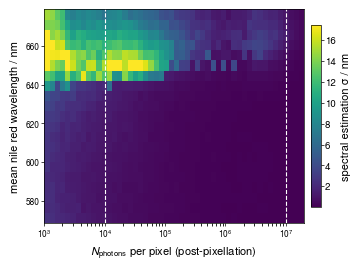

Saved Pixellation_surface_precision.svg


INFO:pyS3M.PlottingBase:Plot saved to: /home/jbeckwith/Documents/Chemistry/Lee/Papers/Multicolour/SI/Nile_Red_Forward_Model/Pixellation_surface_bias.svg


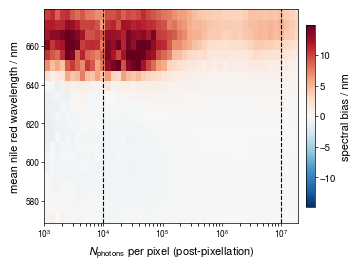

Saved Pixellation_surface_bias.svg


In [47]:
import matplotlib.colors as mcolors

fs = plotter.config.font_size
folder_pt = '/home/jbeckwith/Documents/Chemistry/Lee/Papers/Multicolour/SI/Nile_Red_Forward_Model/'

# Real pixellated render data accumulates ~1e4-1e7 photons per render pixel.
REAL_PHOTONS_PER_PIXEL_RANGE = (1e4, 1e7)


# No trimming needed here any more -- TOTAL_PHOTON_BIN_EDGES already starts at 1000
# (the adaptive MC setup cell above), rather than needing to be cropped after the fact.
photons_to_plot = TOTAL_PHOTON_BIN_CENTERS
surface_precision_toplot = surface_precision
surface_bias_toplot = surface_bias

metric_arrays = [
    ('precision', surface_precision_toplot, 'spectral estimation σ / nm', 'viridis'),
    ('bias', surface_bias_toplot, 'spectral bias / nm', 'RdBu_r'),
]


for name, Z, cbar_lbl, cmap in metric_arrays:
    if name == 'bias':
        # Diverging, centred on zero -- bias can be positive or negative.
        vmax = float(np.nanpercentile(np.abs(Z), 99))
        norm = mcolors.TwoSlopeNorm(vcenter=0.0, vmin=-vmax, vmax=vmax)
    else:
        vmin = float(np.nanmin(Z))
        vmax = float(np.nanpercentile(Z, 99))
        norm = mcolors.Normalize(vmin=vmin, vmax=vmax)

    fig, ax = plt.subplots(figsize=(3.5, 2.6))
    # rasterized=True embeds the mesh as a bitmap in the saved SVG instead of per-quad
    # vector polygons -- avoids thin gray/white seams between adjacent pcolormesh cells
    # on vector export (see Figure1_SBR.ipynb's identical note).
    ax.pcolormesh(
        photons_to_plot, true_wavelengths_com, Z,
        cmap=cmap, shading='auto', norm=norm, rasterized=True,
    )
    ax.set_xscale('log')
    ax.set_xlabel(r'$N_{\rm photons}$ per pixel (post-pixellation)', fontsize=fs + 1)
    # Mean (spectral centre-of-mass) wavelength, not the true PEAK wavelength -- see
    # true_wavelengths_com's definition in the sweep cell above for why.
    ax.set_ylabel('mean nile red wavelength / nm', fontsize=fs + 1)
    ax.tick_params(labelsize=fs - 1)

    # Mark the measured real-data range without obscuring the colour surface
    # underneath (a shaded axvspan would muddy the colours; dashed lines don't).
    if name == 'precision':
        color = 'white'
    else:
        color = 'k'
    for x in REAL_PHOTONS_PER_PIXEL_RANGE:
        ax.axvline(x, color=color, lw=0.8, ls='--')

    fig.colorbar(
        plt.cm.ScalarMappable(norm=norm, cmap=cmap),
        ax=ax, label=cbar_lbl, shrink=0.85, pad=0.03,
    )
    fname = f'Pixellation_surface_{name}.svg'
    plotter.save_or_show(fig, save_path=os.path.join(folder_pt, fname), show=True, dpi=600)
    print(f'Saved {fname}')